In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_housing_data.csv")

In [3]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [6]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 80879.09723486962


In [10]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 10089009300.890661


In [11]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 100444.06055556824


In [12]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9179971706834602


In [13]:
scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='r2'
)
print(scores)

[0.91758995 0.92030155 0.91524299 0.92085038 0.91381118]


In [14]:
print("Average R2:", scores.mean())

Average R2: 0.9175592097606982


In [15]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

In [16]:
ridge_r2 = r2_score(y_test, ridge_pred)
print("Ridge R2:", ridge_r2)

Ridge R2: 0.9179914220241201


In [17]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

In [18]:
lasso_r2 = r2_score(y_test, lasso_pred)
print("Lasso R2:", lasso_r2)

Lasso R2: 0.9179971608478139


In [19]:
params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(
    Ridge(),
    params,
    cv=5,
    scoring='r2'
)
grid.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.01, 0.1, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [20]:
print(grid.best_params_)

{'alpha': 1}


In [21]:
print(grid.best_score_)

0.9174133082098411


In [22]:
residuals = y_test - y_pred

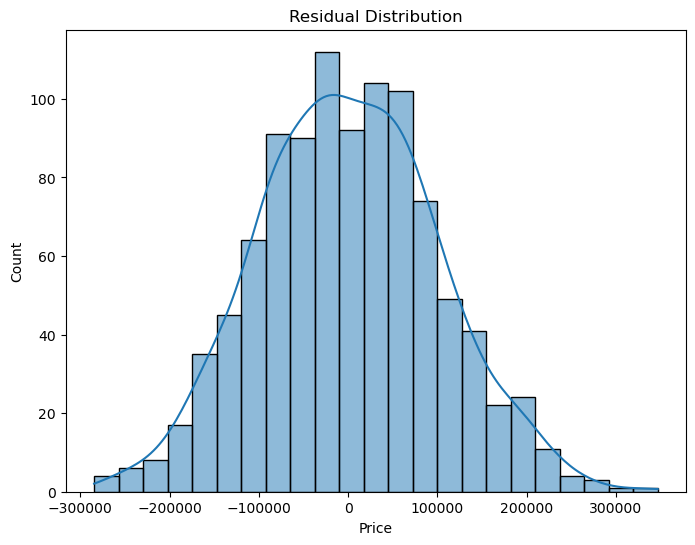

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

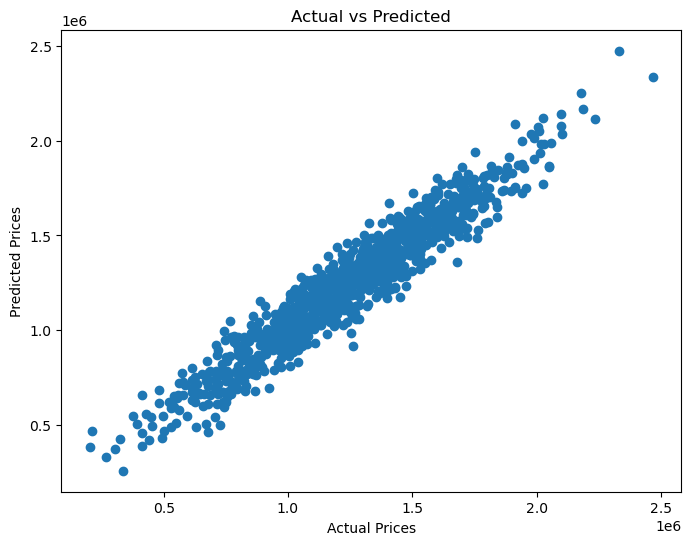

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

In [25]:
comparison = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})
comparison

,Model,R2 Score
0,Linear,0.917997
1,Ridge,0.917991
2,Lasso,0.917997


In [26]:
import pickle
with open("best_model.pkl", "wb") as file:
    pickle.dump(ridge, file)

In [27]:
comparison.to_csv("model_comparison.csv", index=False)